# Tarea M19-CD - YAIR PALOMARES

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import os
os.chdir("/Users/yair_/OneDrive/Desktop/Ciencia de Datos/Módulo 19 - Regresión lineal simple")

In [41]:
df = pd.read_excel("Mexico GDP.xlsx")
df.head()

,Periodo,GDP
0,1960,1.304000e+10
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10


In [32]:
#Se obtiene la muestra para el aprendizaje y prueba
sample = np.random.rand(len(df)) <= 0.80
train = df[sample]
test = df[~sample]

In [33]:
#Función para modelo logístico
def mod_log(x, Beta_1, Beta_2):
    y = 1 / (1 + np.exp(Beta_1 * (x-Beta_2)))
    return y

In [35]:
from scipy.optimize import curve_fit
popt, pcov = curve_fit(mod_log, train["Periodo"], train["GDP"])
print("Beta_1 = ", popt[0], "Beta_2 = ", popt[1])

Beta_1 =  1.0 Beta_2 =  1.0


In [37]:
#Evaluación del modelo
from sklearn.metrics import r2_score
y_hat = mod_log(test["Periodo"], popt[0], popt[1])
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - test["GDP"])))
print("Mean absolute error: %.2f" % np.mean((y_hat - test["GDP"]) **2))
print("R2-score: %.2f" % r2_score(y_hat, test["GDP"]))

Mean absolute error: 567868130746.12
Mean absolute error: 537312549352143274901504.00
R2-score: 0.00


D:\Anaconda\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


#### ¿Tuvo algún problema en el proceso de estimación de parámetros? ¿A qué crees que se debe? 

#### R = Si hubo problemas, debido a que la regresión logística requiere que los datos estén normalizados para funcionar adecuadamente. En este caso en particular, como los valores de x son altos el exponencial tiende a infinito, lo que ocasionaría que la predicción tienda a cero y dificulte el cálculo de los coeficientes. 

In [38]:
#Se normalizan los datos
df["Periodo"] = df["Periodo"] / max(df["Periodo"])
df["GDP"] = df["GDP"] / max(df["GDP"])

#Se obtiene la muestra para el aprendizaje y prueba
sample = np.random.rand(len(df)) <= 0.80
train = df[sample]
test = df[~sample]

#Se vuelven a obtener coeficientes con valores normalizados
popt, pcov = curve_fit(mod_log, train["Periodo"], train["GDP"])
print("Beta_1 = ", popt[0], "Beta_2 = ", popt[1])

Beta_1 =  -278.9200219377052 Beta_2 =  0.9893278064730325


#### ¿Obtuvo resultados satisfactorios en esta ocasión? 

#### R = Se lograron obtener excelentes resultados, ya que el modelo conseguido logra explicar el 98% de la variación del PIB considerando la variable del año.

In [39]:
y_hat = mod_log(test["Periodo"], popt[0], popt[1])
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - test["GDP"])))
print("Mean absolute error: %.2f" % np.mean((y_hat - test["GDP"]) **2))
print("R2-score: %.2f" % r2_score(y_hat, test["GDP"]))

Mean absolute error: 0.03
Mean absolute error: 0.00
R2-score: 0.98


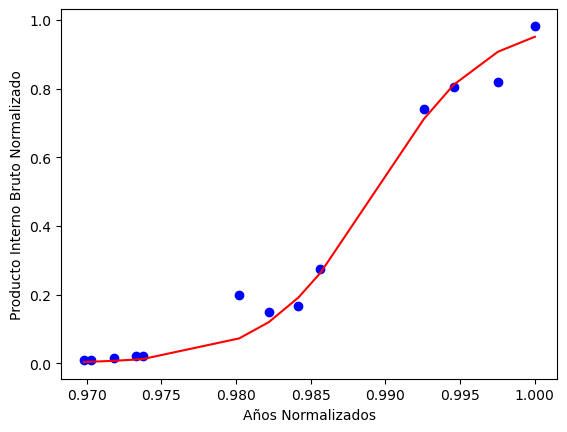

In [40]:
y_ajust = mod_log(test["Periodo"], popt[0], popt[1])
plt.plot(test["Periodo"], test["GDP"], "bo")
plt.plot(test["Periodo"], y_ajust, "r")
plt.ylabel("Producto Interno Bruto Normalizado")
plt.xlabel("Años Normalizados")
plt.show()

#### ¿Cuál sería su pronóstico del PIB (GDP) para México en el 2022?  

#### R = El pronóstico para el valor del PIB de México para el 2022, es un valor de $1,259,442,211,777.935

In [45]:
y_ajust_2022 = mod_log(2022/max(df["Periodo"]), popt[0], popt[1])
y_ajust_2022 = y_ajust_2022 * max(df["GDP"])
y_ajust_2022

1259442211777.935

#### ¿Qué mecanismo de transformación tendría que realizar en dicho caso?  

#### R = Para interpretar la respuesta final del pronóstico, se tuvo que desnormalizar el resultado, multiplicando por el valor máximo que se había considerado para la normalización de la variable.